In [1]:
sc

<SparkContext master=local[*] appName=PySparkShell>

In [35]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, NumericType, lit, countDistinct, count, sum, avg, mean, median, stddev, max, min, isnan, when, corr, round

# Initialize Spark Session
spark = SparkSession.builder.appName("RainfallDataAnalysis").getOrCreate()

# Load the CSV file
df = spark.read.csv("Rainfall-Data.csv", header=True, inferSchema=True)

# Display a few rows
df.show(5)

+---------+----------+----------+----+-----+------------+--------------+
|    State|  District|      Date|Year|Month|Avg_rainfall|   Agency_name|
+---------+----------+----------+----+-----+------------+--------------+
|Telangana|Mancherial|2025-01-30|2025|    1|         0.0|NRSC VIC MODEL|
|Telangana|Mancherial|2025-02-06|2025|    2|         0.0|NRSC VIC MODEL|
|Telangana|Mancherial|2025-02-07|2025|    2|         0.0|NRSC VIC MODEL|
|Telangana|Mancherial|2025-02-08|2025|    2|         0.0|NRSC VIC MODEL|
|Telangana|Mancherial|2025-02-19|2025|    2|         0.0|NRSC VIC MODEL|
+---------+----------+----------+----+-----+------------+--------------+
only showing top 5 rows


# How many total records (rows) are present?

In [3]:
df.count()

10000

# How many columns are present, and what are their names?

In [4]:
len(df.columns), df.columns

(7,
 ['State', 'District', 'Date', 'Year', 'Month', 'Avg_rainfall', 'Agency_name'])

# What are the data types of each column?

In [5]:
df.printSchema()

root
 |-- State: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Avg_rainfall: double (nullable = true)
 |-- Agency_name: string (nullable = true)



# How many missing (NaN) values are there in each column?

In [10]:
missing_counts = df.select([
    count(
        when(
            col(c).isNull() | 
            (isnan(col(c)) if dict(df.dtypes)[c] in ['double', 'float'] else lit(False)),
            c
        )
    ).alias(c)
    for c in df.columns
])

missing_counts.show()

+-----+--------+----+----+-----+------------+-----------+
|State|District|Date|Year|Month|Avg_rainfall|Agency_name|
+-----+--------+----+----+-----+------------+-----------+
|    0|       0|   0|   0|    0|           0|          0|
+-----+--------+----+----+-----+------------+-----------+



# How many unique values are present in each column?

In [7]:
df.select([countDistinct(col(c)).alias(c) for c in df.columns]).show()

+-----+--------+----+----+-----+------------+-----------+
|State|District|Date|Year|Month|Avg_rainfall|Agency_name|
+-----+--------+----+----+-----+------------+-----------+
|    1|      33| 175|   1|    6|        3274|          1|
+-----+--------+----+----+-----+------------+-----------+



# How many distinct districts are present?

In [11]:
df.select(countDistinct("district")).show()

+------------------------+
|count(DISTINCT district)|
+------------------------+
|                      33|
+------------------------+



# How many distinct states are represented?

In [13]:
df.select(countDistinct("State").alias("Distinct_States")).show()

+---------------+
|Distinct_States|
+---------------+
|              1|
+---------------+



# Which district recorded the highest average rainfall?

In [14]:
df.groupBy("district").avg("Avg_rainfall").orderBy(col("avg(Avg_rainfall)").desc()).show(1)

+--------------------+-----------------+
|            district|avg(Avg_rainfall)|
+--------------------+-----------------+
|Bhadradri Kothagudem|2.398630089734469|
+--------------------+-----------------+
only showing top 1 row


# Which district recorded the lowest average rainfall?

In [15]:
df.groupBy("district").avg("Avg_rainfall").orderBy(col("avg(Avg_rainfall)").asc()).show(1)

+--------+------------------+
|district| avg(Avg_rainfall)|
+--------+------------------+
|Nalgonda|1.0653518781518396|
+--------+------------------+
only showing top 1 row


# What are the top 5 districts with the highest total rainfall?

In [16]:
df.groupBy("district").sum("Avg_rainfall").orderBy(col("sum(Avg_rainfall)").desc()).show(5)

+--------------------+-----------------+
|            district|sum(Avg_rainfall)|
+--------------------+-----------------+
|Bhadradri Kothagudem|702.7986162921994|
|Kumuram Bheem Asi...|640.8085741291999|
|               Medak|631.1172876491999|
|              Mulugu|629.5587029326997|
|           Nizamabad|616.4901992080003|
+--------------------+-----------------+
only showing top 5 rows


# What is the total rainfall recorded across all entries?

In [17]:
df.agg(sum("Avg_rainfall").alias("Total_Rainfall")).show()

+------------------+
|    Total_Rainfall|
+------------------+
|16019.941572762058|
+------------------+



# What is the average rainfall across the dataset?

In [18]:
df.agg(avg("Avg_rainfall").alias("Average_Rainfall")).show()

+------------------+
|  Average_Rainfall|
+------------------+
|1.6019941572762058|
+------------------+



# What is the median of the rainfall column?

In [19]:
# Approximate median using approxQuantile
median_val = df.approxQuantile("Avg_rainfall", [0.5], 0.01)
print("Median Rainfall:", median_val[0])

Median Rainfall: 0.000480279


# What is the standard deviation of rainfall values?

In [20]:
df.agg(stddev("Avg_rainfall").alias("Std_Deviation")).show()

+-----------------+
|    Std_Deviation|
+-----------------+
|5.149971435919993|
+-----------------+



# What are the maximum and minimum rainfall values?

In [21]:
df.agg(max("Avg_rainfall").alias("Max_Rainfall"), min("Avg_rainfall").alias("Min_Rainfall")).show()

+-------------+-------------+
| Max_Rainfall| Min_Rainfall|
+-------------+-------------+
|60.1317892922|-0.0345444433|
+-------------+-------------+



# How many records show rainfall > 0 mm and their percentage?

In [22]:
total = df.count()
rainy = df.filter(col("Avg_rainfall") > 0).count()
percentage = (rainy / total) * 100
print(f"Rainy Records: {rainy}, Percentage: {percentage:.2f}%")

Rainy Records: 5890, Percentage: 58.90%


# How many records have zero or missing rainfall?

In [23]:
zero_rain = df.filter(col("Avg_rainfall") == 0).count()
missing_rain = df.filter(col("Avg_rainfall").isNull()).count()
print(f"Zero Rainfall: {zero_rain}, Missing: {missing_rain}")

Zero Rainfall: 4071, Missing: 0


# Which year had the highest total rainfall?

In [24]:
df.groupBy("year").sum("Avg_rainfall").orderBy(col("sum(Avg_rainfall)").desc()).show(1)

+----+------------------+
|year| sum(Avg_rainfall)|
+----+------------------+
|2025|16019.941572762058|
+----+------------------+



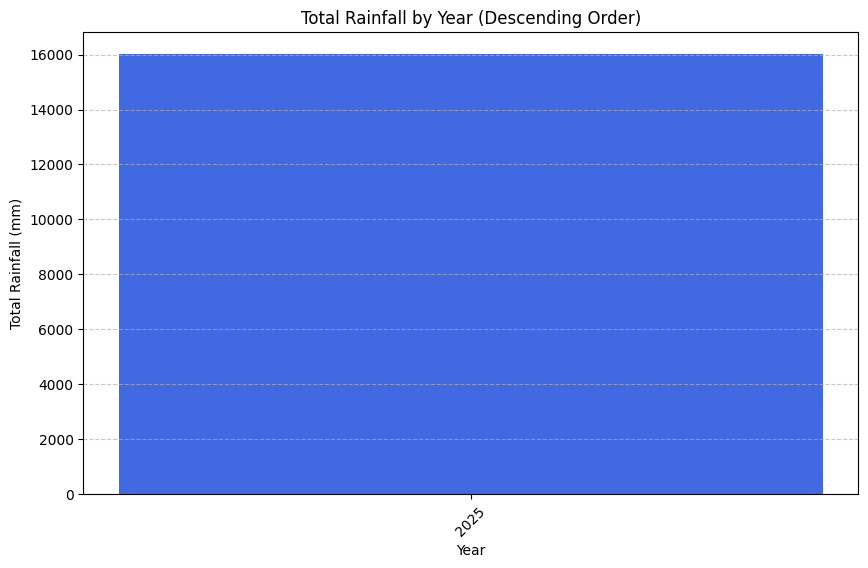

In [37]:
from pyspark.sql.functions import col, sum as _sum
import matplotlib.pyplot as plt

# Step 1: Group by Year and sum the rainfall
yearly_rainfall_df = (
    df.groupBy("Year")
      .agg(_sum("Avg_rainfall").alias("Total_Rainfall"))
      .orderBy(col("Total_Rainfall").desc())
)

# Step 2: Convert to Pandas for visualization
yearly_rainfall_pd = yearly_rainfall_df.toPandas()

# Step 3: Plot the graph
plt.figure(figsize=(10, 6))
plt.bar(yearly_rainfall_pd["Year"].astype(str), yearly_rainfall_pd["Total_Rainfall"], color="royalblue")
plt.title("Total Rainfall by Year (Descending Order)")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Which month recorded the highest average rainfall?

In [25]:
df.groupBy("month").avg("Avg_rainfall").orderBy(col("avg(Avg_rainfall)").desc()).show(1)

+-----+-----------------+
|month|avg(Avg_rainfall)|
+-----+-----------------+
|    5|5.279224024780309|
+-----+-----------------+
only showing top 1 row


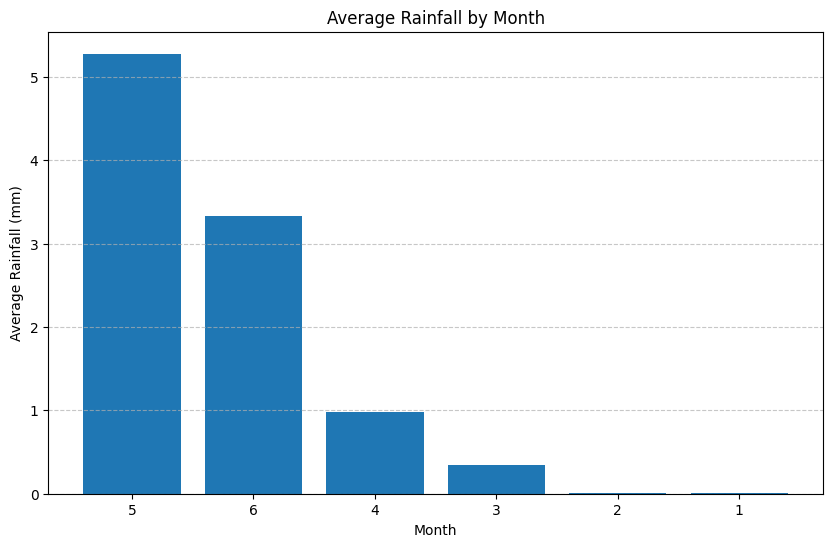

In [32]:
import matplotlib.pyplot as plt

# Step 1: Compute average rainfall per month
monthly_avg_df = (
    df.groupBy("Month")
      .agg(avg("Avg_rainfall").alias("Average_Rainfall"))
      .orderBy(col("Average_Rainfall").desc())
)

# Step 2: Convert to Pandas for plotting
monthly_avg_pd = monthly_avg_df.toPandas()

# Step 3: Plot
plt.figure(figsize=(10, 6))
plt.bar(monthly_avg_pd["Month"].astype(str), monthly_avg_pd["Average_Rainfall"])
plt.title("Average Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Which numeric column is most correlated with Avg_rainfall?

In [31]:
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType) and f.name != "Avg_rainfall"]

print("Numeric columns found:", numeric_cols)
print("-" * 50)

for col_name in numeric_cols:
    # Check if column has more than 1 distinct value
    distinct_count = df.select(countDistinct(col(col_name))).collect()[0][0]
    if distinct_count <= 1:
        print(f"Skipping {col_name}: constant values (cannot compute correlation)")
        continue
    
    try:
        correlation = df.stat.corr("Avg_rainfall", col_name)
        print(f"Correlation between Avg_rainfall and {col_name}: {correlation}")
    except Exception as e:
        print(f"Could not compute correlation for {col_name}: {e}")

Numeric columns found: ['Year', 'Month']
--------------------------------------------------
Skipping Year: constant values (cannot compute correlation)
Correlation between Avg_rainfall and Month: 0.30583053791222603
